<a href="https://colab.research.google.com/github/1BM23CS345/6Sem_ML_Lab/blob/main/1BM23CS345_Lab_11_PCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# NOTE: Replace 'your_dataframe' with your actual preprocessed DataFrame.
# For demonstration, we'll create a dummy DataFrame.
# In a real scenario, 'df_processed' would be the result of your data cleaning and preprocessing steps.
# Ensure 'df_processed' contains only numerical features you want to apply PCA on.

# Dummy DataFrame for demonstration
np.random.seed(42)
data = {
    'feature1': np.random.rand(100) * 10,
    'feature2': np.random.rand(100) * 5,
    'feature3': np.random.rand(100) * 15,
    'feature4': np.random.rand(100) * 8,
    'feature5': np.random.rand(100) * 12
}
df_processed = pd.DataFrame(data)

print("Original DataFrame head:")
display(df_processed.head())
print("Original DataFrame shape:", df_processed.shape)

Original DataFrame head:


,feature1,feature2,feature3,feature4,feature5
0,3.745401,0.157146,9.630475,0.413454,1.237486
1,9.507143,3.182052,1.262099,4.250837,10.830635
2,7.319939,1.571780,2.424431,4.325081,6.063028
3,5.986585,2.542853,13.478313,5.099439,9.917490
4,1.560186,4.537832,9.096436,5.808731,3.840595


Original DataFrame shape: (100, 5)


In [2]:
# Initialize StandardScaler
scaler = StandardScaler()

# Fit and transform the data
df_scaled = scaler.fit_transform(df_processed)

# Convert scaled data back to a DataFrame for easier inspection (optional)
df_scaled_df = pd.DataFrame(df_scaled, columns=df_processed.columns)

print("Scaled DataFrame head:")
display(df_scaled_df.head())

Scaled DataFrame head:


,feature1,feature2,feature3,feature4,feature5
0,-0.323112,-1.599230,0.426196,-1.505121,-1.302577
1,1.623434,0.475167,-1.484683,0.137700,1.219250
2,0.884509,-0.629113,-1.219270,0.169484,-0.034048
3,0.434049,0.036822,1.304832,0.500994,0.979205
4,-1.061365,1.404924,0.304251,0.804649,-0.618277


### 2. Apply PCA

Now we'll apply PCA. We can initially fit PCA to all components to determine the optimal number of components based on explained variance.

In [3]:
# Initialize PCA with all components (n_components=None)
pca = PCA(n_components=None)

# Fit PCA to the scaled data
pca.fit(df_scaled)

print("Explained variance ratio for each component:")
print(pca.explained_variance_ratio_)

Explained variance ratio for each component:
[0.26598212 0.23311403 0.21912428 0.16343104 0.11834852]


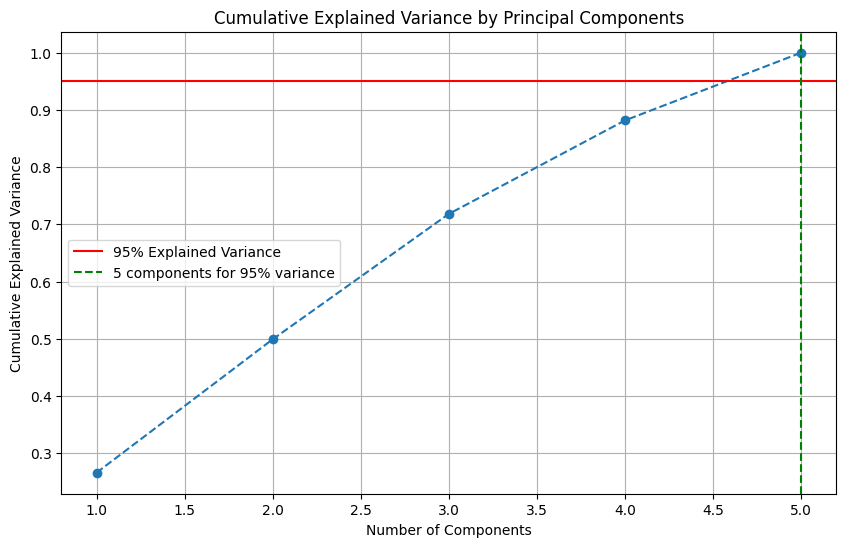

Number of components to explain 95% variance: 5


In [4]:
# Calculate cumulative explained variance
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

# Plot explained variance
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--')
plt.title('Cumulative Explained Variance by Principal Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)

# Add a line for a common threshold, e.g., 95%
plt.axhline(y=0.95, color='r', linestyle='-', label='95% Explained Variance')
plt.legend(loc='best')

# Find the number of components for 95% variance
num_components_95 = np.where(cumulative_variance >= 0.95)[0][0] + 1
plt.axvline(x=num_components_95, color='g', linestyle='--', label=f'{num_components_95} components for 95% variance')
plt.legend(loc='best')

plt.show()

print(f"Number of components to explain 95% variance: {num_components_95}")

In [5]:
# Re-initialize PCA with the desired number of components (e.g., num_components_95)
n_components = num_components_95 # Or manually choose a number based on the plot
pca = PCA(n_components=n_components)

# Fit and transform the scaled data to get the reduced dimensions
df_pca = pca.fit_transform(df_scaled)

# Create a DataFrame for the PCA results
pca_columns = [f'PC{i+1}' for i in range(n_components)]
df_pca_df = pd.DataFrame(data=df_pca, columns=pca_columns)

print(f"DataFrame after PCA with {n_components} components:")
display(df_pca_df.head())
print("Shape of the DataFrame after PCA:", df_pca_df.shape)

DataFrame after PCA with 5 components:


,PC1,PC2,PC3,PC4,PC5
0,-1.864870,-0.297612,-0.948269,-1.375578,-0.669279
1,0.859380,1.215626,2.081099,-0.111819,-0.106685
2,0.391711,0.622218,0.816547,-1.219545,-0.003445
3,-0.161614,1.035700,-0.417363,1.161548,0.692820
4,0.766497,-1.568132,-0.359511,0.873533,0.532668


Shape of the DataFrame after PCA: (100, 5)
